In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [3]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400
2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400
2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800
2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400
2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800
...,...,...,...,...,...
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400
2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400
2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800
2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400
2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800


In [5]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100
2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50154100


# 2. Data Exploration

In [6]:
type(df)

pandas.core.frame.DataFrame

In [7]:
df.shape

(2513, 5)

In [8]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [9]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,121.307319,122.518018,119.984728,121.203031,9.793575e+07
std,75.565249,76.299416,74.773067,75.512903,5.592679e+07
min,20.584812,20.887868,20.386576,20.507344,1.791060e+07
25%,44.362309,44.624273,44.023090,44.314057,5.872410e+07
50%,127.437599,128.793767,125.714044,127.527222,8.614160e+07
75%,177.058609,178.498067,175.138150,177.161694,1.188540e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [10]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [11]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400
2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400
2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800
2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400
2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800


In [12]:
df=df.reset_index()

In [13]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800
...,...,...,...,...,...,...
2508,2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2509,2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100
2510,2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200


In [14]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,2021-04-19 02:00:20.055710464,121.307319,122.518018,119.984728,121.203031,9.793575e+07
min,2016-04-22 00:00:00,20.584812,20.887868,20.386576,20.507344,1.791060e+07
25%,2018-10-18 00:00:00,44.362309,44.624273,44.023090,44.314057,5.872410e+07
50%,2021-04-20 00:00:00,127.437599,128.793767,125.714044,127.527222,8.614160e+07
75%,2023-10-17 00:00:00,177.058609,178.498067,175.138150,177.161694,1.188540e+08
max,2026-04-21 00:00:00,285.922455,288.350192,283.035157,285.932471,4.584084e+08
std,NaN,75.565249,76.299416,74.773067,75.512903,5.592679e+07


In [15]:
df

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800
...,...,...,...,...,...,...
2508,2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500
2509,2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100
2510,2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200


Text(0, 0.5, 'ClosevPrice')

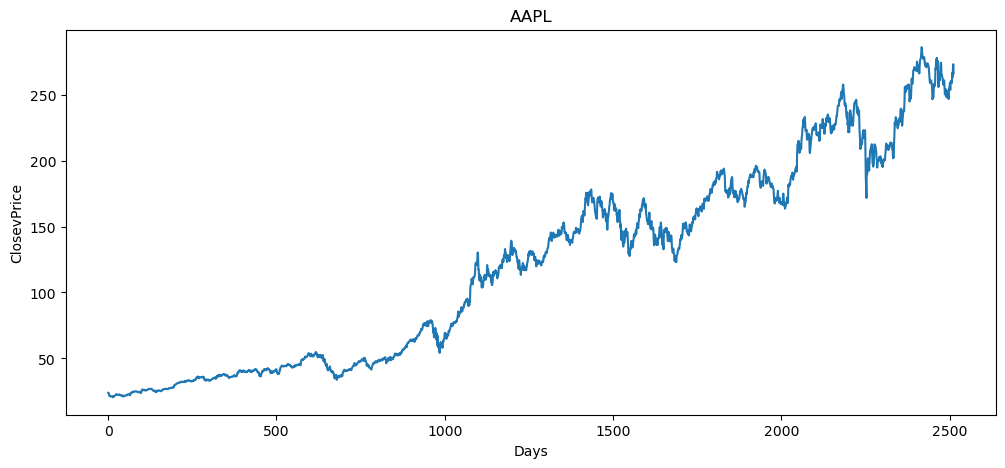

In [16]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('ClosevPrice')

## Feature Engineering

In [17]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[2:7])/5)

50.0


In [18]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [19]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


## 100 days Moving Average

In [20]:
df.columns = df.columns.get_level_values(0)
df['MA_100'] = df.Close.rolling(100).mean()
df.head(110)

Price,Date,Close,High,Low,Open,Volume,MA_100
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400,NaN
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400,NaN
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800,NaN
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400,NaN
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800,NaN
...,...,...,...,...,...,...,...
105,2016-09-21,26.013592,26.114392,25.759298,26.082319,144012800,23.062597
106,2016-09-22,26.258728,26.332038,26.116689,26.196872,124296000,23.113108
107,2016-09-23,25.821157,26.297673,25.555410,26.212908,209924800,23.155755
108,2016-09-26,25.860100,25.976938,25.555406,25.576024,119477600,23.201034


In [21]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400,NaN,NaN
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400,NaN,NaN
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800,NaN,NaN
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400,NaN,NaN
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800,NaN,NaN
...,...,...,...,...,...,...,...,...
198,2017-02-03,29.723242,29.748572,29.511394,29.545933,98029200,26.443398,NaN
199,2017-02-06,30.001863,30.050222,29.681788,29.734753,107383600,26.496110,24.678184
200,2017-02-07,30.287399,30.416350,30.038707,30.059431,152735200,26.542926,24.709949
201,2017-02-08,30.404852,30.446302,30.216032,30.245969,92016400,26.582211,24.742980


Text(0, 0.5, 'Price')

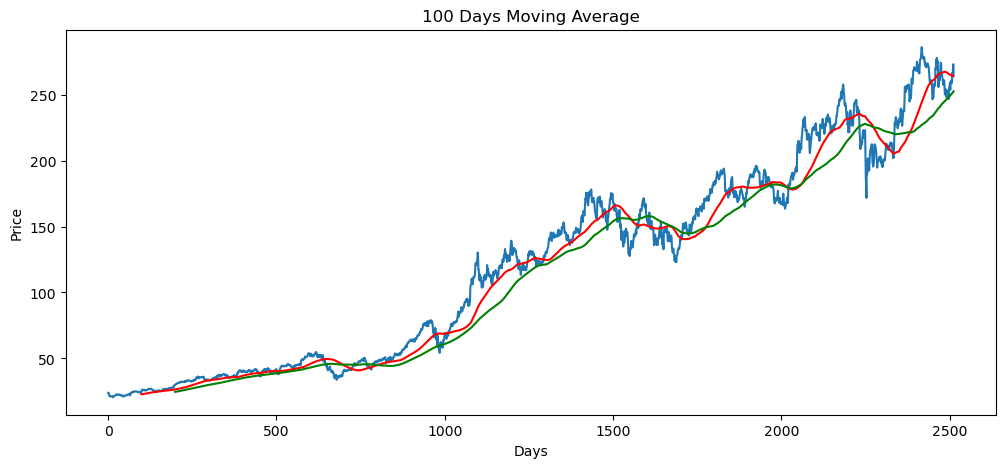

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')

In [23]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400,NaN,NaN
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400,NaN,NaN
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800,NaN,NaN
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400,NaN,NaN
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800,NaN,NaN
...,...,...,...,...,...,...,...,...
2508,2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500,264.443185,251.218368
2509,2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100,264.394095,251.512630
2510,2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200,264.436384,251.827833
2511,2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200,264.454522,252.134105


### Calculating % changed in each trading session

In [24]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

Price,Close,Percentage Changed
0,23.934450,NaN
1,23.798561,-0.005678
2,23.633232,-0.006947
3,22.154314,-0.062578
4,21.477135,-0.030566
...,...,...
2508,266.429993,0.029363
2509,263.399994,-0.011373
2510,270.230011,0.025930
2511,273.049988,0.010435


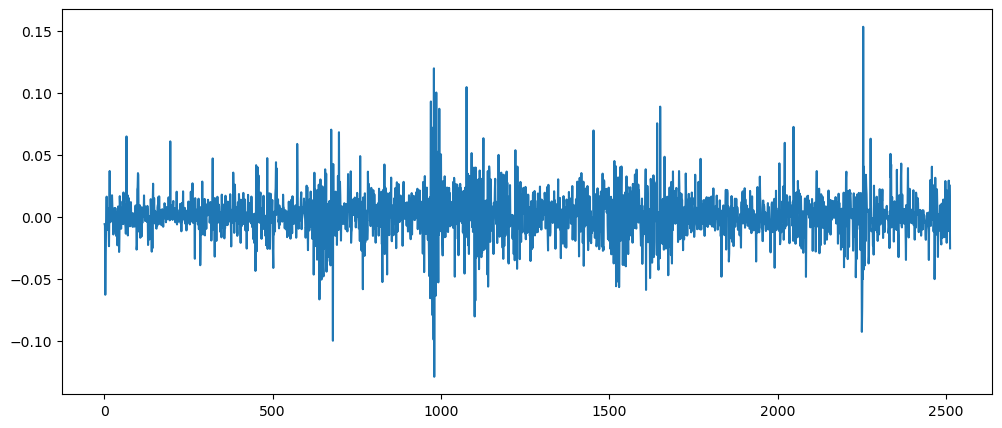

In [25]:
plt.figure(figsize=(12, 5))
plt.plot(df['Percentage Changed'])

## 4. Data Preprocessing

In [26]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage Changed
0,2016-04-22,23.934450,24.115635,23.694381,23.782709,134732400,NaN,NaN,NaN
1,2016-04-25,23.798561,23.927655,23.669467,23.780442,112126400,NaN,NaN,-0.005678
2,2016-04-26,23.633232,23.848390,23.533582,23.533582,224064800,NaN,NaN,-0.006947
3,2016-04-27,22.154314,22.355881,21.669646,21.742120,458408400,NaN,NaN,-0.062578
4,2016-04-28,21.477135,22.167899,21.345776,22.106750,328970800,NaN,NaN,-0.030566
...,...,...,...,...,...,...,...,...,...
2508,2026-04-15,266.429993,266.559998,257.809998,258.160004,49913500,264.443185,251.218368,0.029363
2509,2026-04-16,263.399994,267.160004,261.269989,266.799988,43323100,264.394095,251.512630,-0.011373
2510,2026-04-17,270.230011,272.299988,266.720001,266.959991,61436200,264.436384,251.827833,0.025930
2511,2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200,264.454522,252.134105,0.010435


In [27]:
df.shape

(2513, 9)

In [28]:
# Splitting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_training)
print(data_testing)

           Close
0      23.934450
1      23.798561
2      23.633232
3      22.154314
4      21.477135
...          ...
1754  157.813736
1755  163.195724
1756  162.850784
1757  162.870453
1758  164.092773

[1759 rows x 1 columns]
           Close
1759  165.236221
1760  164.270203
1761  162.663483
1762  162.969055
1763  161.431335
...          ...
2508  266.429993
2509  263.399994
2510  270.230011
2511  273.049988
2512  266.170013

[754 rows x 1 columns]


# Scaling down the data b/w 0 & 1m

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [30]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.021265  ],
       [0.02040231],
       [0.01935273],
       ...,
       [0.90316789],
       [0.90329275],
       [0.91105259]], shape=(1759, 1))

In [31]:
type(data_training_array)
data_training_array.shape

(1759, 1)

## 5. Sequence Creation

In [32]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [33]:
x_train

array([[[0.021265  ],
        [0.02040231],
        [0.01935273],
        ...,
        [0.01930961],
        [0.02266924],
        [0.02631973]],

       [[0.02040231],
        [0.01935273],
        [0.0099639 ],
        ...,
        [0.02266924],
        [0.02631973],
        [0.0318755 ]],

       [[0.01935273],
        [0.0099639 ],
        [0.00566486],
        ...,
        [0.02631973],
        [0.0318755 ],
        [0.03740223]],

       ...,

       [[0.81105448],
        [0.81461599],
        [0.79412177],
        ...,
        [0.87557099],
        [0.87119045],
        [0.90535772]],

       [[0.81461599],
        [0.79412177],
        [0.80768042],
        ...,
        [0.87119045],
        [0.90535772],
        [0.90316789]],

       [[0.79412177],
        [0.80768042],
        [0.8132416 ],
        ...,
        [0.90535772],
        [0.90316789],
        [0.90329275]]], shape=(1659, 100, 1))

## 6.Model Building

In [34]:
import tensorflow as tf

In [35]:
print(tf.__version__)

2.21.0


In [36]:
# ML model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [37]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

## 7.Model Training

In [38]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0114
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 6.7164e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 6.2486e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 6.8654e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 5.6972e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 5.8059e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 5.4365e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 5.3798e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 5.0702e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 4.9743e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 5.8503e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 5.4384e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 4.6909e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 4.3440e-04
Epoch 15/50
52/52 ━

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [40]:
# Save the trained model
model.save('stock_prediction_model.keras')

In [42]:
## 8.Preparing Test Data
data_training.tail(100)

,Close
1659,147.809708
1660,148.685699
1661,145.772385
1662,141.943802
1663,138.941925
...,...
1754,157.813736
1755,163.195724
1756,162.850784
1757,162.870453


In [43]:
data_testing

,Close
1759,165.236221
1760,164.270203
1761,162.663483
1762,162.969055
1763,161.431335
...,...
2508,266.429993
2509,263.399994
2510,270.230011
2511,273.049988


In [44]:
past_100_days = data_training.tail(100)

In [45]:
past_100_days

,Close
1659,147.809708
1660,148.685699
1661,145.772385
1662,141.943802
1663,138.941925
...,...
1754,157.813736
1755,163.195724
1756,162.850784
1757,162.870453


In [47]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

,Close
0,147.809708
1,148.685699
2,145.772385
3,141.943802
4,138.941925
...,...
849,266.429993
850,263.399994
851,270.230011
852,273.049988


In [48]:
input_data = scaler.fit_transform(final_df)
input_data

array([[1.52035666e-01],
       [1.57413952e-01],
       [1.39527210e-01],
       [1.16021041e-01],
       [9.75905591e-02],
       [1.39043803e-01],
       [1.40735730e-01],
       [1.37714338e-01],
       [1.30583886e-01],
       [1.08104771e-01],
       [9.62007619e-02],
       [1.06533789e-01],
       [1.03572730e-01],
       [1.17652448e-01],
       [1.23574380e-01],
       [1.09917644e-01],
       [6.93708832e-02],
       [5.73457412e-02],
       [4.44143033e-02],
       [4.39912278e-02],
       [6.30259694e-02],
       [4.35683398e-02],
       [4.13324853e-02],
       [3.02741587e-02],
       [6.16372964e-03],
       [2.77363149e-02],
       [2.96699459e-02],
       [3.02270358e-04],
       [8.09740741e-03],
       [0.00000000e+00],
       [2.77965535e-02],
       [3.09993640e-02],
       [3.45041637e-02],
       [5.11823863e-02],
       [5.06989785e-02],
       [5.88564840e-02],
       [6.59869354e-02],
       [6.15756525e-02],
       [6.19383020e-02],
       [7.76494280e-02],


In [49]:
input_data.shape

(854, 1)

In [50]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100: i])
    y_test.append(input_data[i, 0])

In [51]:
x_test,y_test = np.array(x_test), np.array(y_test)

In [52]:
x_test

array([[[0.15203567],
        [0.15741395],
        [0.13952721],
        ...,
        [0.24438266],
        [0.24450342],
        [0.25200804]],

       [[0.15741395],
        [0.13952721],
        [0.11602104],
        ...,
        [0.24450342],
        [0.25200804],
        [0.25902841]],

       [[0.13952721],
        [0.11602104],
        [0.09759056],
        ...,
        [0.25200804],
        [0.25902841],
        [0.25309739]],

       ...,

       [[0.87768979],
        [0.90983134],
        [0.93700485],
        ...,
        [0.83366165],
        [0.88032305],
        [0.86171991]],

       [[0.90983134],
        [0.93700485],
        [0.94344542],
        ...,
        [0.88032305],
        [0.86171991],
        [0.90365384]],

       [[0.93700485],
        [0.94344542],
        [0.94700296],
        ...,
        [0.86171991],
        [0.90365384],
        [0.92096752]]], shape=(754, 100, 1))

In [53]:
y_test

array([0.25902841, 0.25309739, 0.24323269, 0.2451088 , 0.23566773,
       0.23560703, 0.26374876, 0.27143485, 0.27089008, 0.26453561,
       0.25793896, 0.2478927 , 0.29497708, 0.29455363, 0.28408345,
       0.29491647, 0.29606644, 0.29036972, 0.28733971, 0.28733971,
       0.29109689, 0.30539949, 0.30606595, 0.3002481 , 0.28424862,
       0.28594551, 0.2929152 , 0.30770214, 0.31903533, 0.31873208,
       0.33594355, 0.34115536, 0.33285274, 0.33061032, 0.32218648,
       0.33885233, 0.34121606, 0.35836673, 0.35545776, 0.35933627,
       0.37182065, 0.3652152 , 0.36576044, 0.35939716, 0.37782052,
       0.37588108, 0.3673362 , 0.38424441, 0.39145637, 0.39351694,
       0.42006118, 0.41091006, 0.40406197, 0.40697066, 0.40012239,
       0.38757768, 0.38436564, 0.39460761, 0.39927408, 0.40018319,
       0.4201824 , 0.41860664, 0.42690945, 0.41497041, 0.40775864,
       0.41266747, 0.4179399 , 0.42327293, 0.41551593, 0.43133338,
       0.43509066, 0.43000008, 0.41163714, 0.40309207, 0.34745

## 9.Prediction Making

In [54]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step


In [55]:
y_predicted

array([[0.24790607],
       [0.25385958],
       [0.2549877 ],
       [0.25050697],
       [0.24736123],
       [0.24198337],
       [0.23837464],
       [0.248006  ],
       [0.26000646],
       [0.26752064],
       [0.2682265 ],
       [0.26429892],
       [0.25679323],
       [0.27102634],
       [0.28405875],
       [0.28705072],
       [0.29118276],
       [0.2941288 ],
       [0.293076  ],
       [0.29035312],
       [0.28847724],
       [0.28924668],
       [0.2964567 ],
       [0.30231026],
       [0.30289033],
       [0.29521173],
       [0.28987098],
       [0.2902329 ],
       [0.29804233],
       [0.30910385],
       [0.315974  ],
       [0.32651213],
       [0.33530688],
       [0.33593798],
       [0.3335364 ],
       [0.32777128],
       [0.33141717],
       [0.3364465 ],
       [0.34745488],
       [0.35340795],
       [0.35743442],
       [0.36489373],
       [0.36639294],
       [0.36628446],
       [0.36291638],
       [0.36909413],
       [0.3733533 ],
       [0.371

In [56]:
y_test

array([0.25902841, 0.25309739, 0.24323269, 0.2451088 , 0.23566773,
       0.23560703, 0.26374876, 0.27143485, 0.27089008, 0.26453561,
       0.25793896, 0.2478927 , 0.29497708, 0.29455363, 0.28408345,
       0.29491647, 0.29606644, 0.29036972, 0.28733971, 0.28733971,
       0.29109689, 0.30539949, 0.30606595, 0.3002481 , 0.28424862,
       0.28594551, 0.2929152 , 0.30770214, 0.31903533, 0.31873208,
       0.33594355, 0.34115536, 0.33285274, 0.33061032, 0.32218648,
       0.33885233, 0.34121606, 0.35836673, 0.35545776, 0.35933627,
       0.37182065, 0.3652152 , 0.36576044, 0.35939716, 0.37782052,
       0.37588108, 0.3673362 , 0.38424441, 0.39145637, 0.39351694,
       0.42006118, 0.41091006, 0.40406197, 0.40697066, 0.40012239,
       0.38757768, 0.38436564, 0.39460761, 0.39927408, 0.40018319,
       0.4201824 , 0.41860664, 0.42690945, 0.41497041, 0.40775864,
       0.41266747, 0.4179399 , 0.42327293, 0.41551593, 0.43133338,
       0.43509066, 0.43000008, 0.41163714, 0.40309207, 0.34745

In [57]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [58]:
y_predicted

array([163.42467, 164.39433, 164.57808, 163.84828, 163.33592, 162.46   ,
       161.87222, 163.44095, 165.39552, 166.61938, 166.73438, 166.09467,
       164.87216, 167.19038, 169.31305, 169.80038, 170.47339, 170.95322,
       170.78174, 170.33826, 170.03271, 170.15805, 171.33238, 172.28578,
       172.38026, 171.1296 , 170.25974, 170.31868, 171.59064, 173.3923 ,
       174.51128, 176.22768, 177.66013, 177.76292, 177.37177, 176.43275,
       177.02658, 177.84573, 179.63873, 180.60834, 181.26416, 182.4791 ,
       182.72328, 182.70561, 182.15704, 183.16325, 183.85696, 183.53761,
       184.47299, 185.7556 , 186.66573, 189.148  , 189.98929, 189.56694,
       189.32649, 188.68413, 187.31859, 186.26314, 186.58945, 187.40787,
       188.02701, 189.8928 , 190.94435, 191.97975, 191.50731, 190.40482,
       190.10979, 190.52888, 191.32498, 191.20146, 192.25336, 193.29158,
       193.40184, 191.80475, 190.01912, 184.75217, 180.08255, 178.14644,
       176.93446, 176.37952, 176.2552 , 177.00447, 

In [59]:
y_test

array([165.23622131, 164.27020264, 162.66348267, 162.96905518,
       161.43133545, 161.42144775, 166.00505066, 167.25692749,
       167.16819763, 166.13320923, 165.05877686, 163.42248535,
       171.09138489, 171.02241516, 169.31707764, 171.08151245,
       171.26881409, 170.34095764, 169.84744263, 169.84744263,
       170.45939636, 172.78894043, 172.89749146, 171.9499054 ,
       169.34397888, 169.62036133, 170.7555542 , 173.16398621,
       175.0098877 , 174.960495  , 177.76382446, 178.61270142,
       177.26040649, 176.89517212, 175.52313232, 178.2375946 ,
       178.62258911, 181.41601562, 180.94221497, 181.57392883,
       183.60733032, 182.53146362, 182.62026978, 181.58384705,
       184.58456421, 184.26867676, 182.87692261, 185.63085938,
       186.80551147, 187.14112854, 191.46453857, 189.9740448 ,
       188.85865784, 189.33241272, 188.21699524, 186.17376709,
       185.65060425, 187.31877136, 188.0788269 , 188.22689819,
       191.48428345, 191.22763062, 192.57995605, 190.63

(140.0, 220.0)

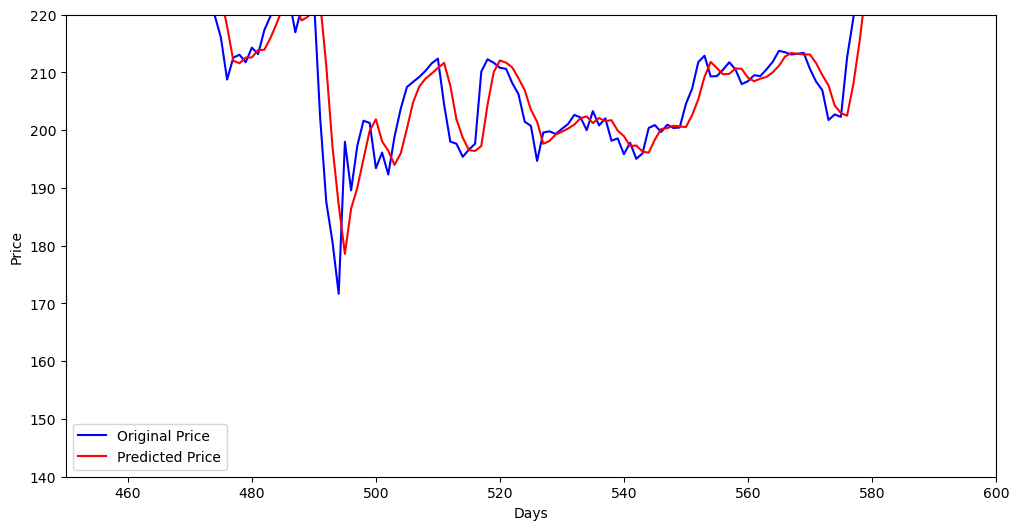

In [63]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 600)
plt.ylim(140, 220)

# 10. Modle Evaluation

In [71]:
# MEan Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [65]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 15.141196323136562


In [66]:
# Root Mean Squared Error (RMSE)


In [69]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 3.8911690175494256


In [72]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared: {r2}")

R-Squared: 0.9861508337377215
